# Section 6.5

## Example 6.5.1

Let's run adaptive RK on  $u'=e^{t-u\sin u}$.

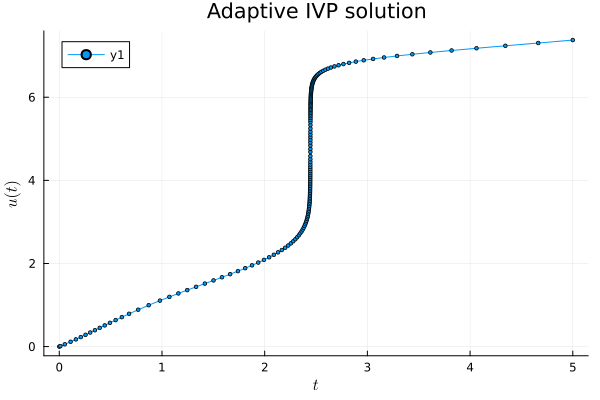

In [1]:
using OrdinaryDiffEq, Plots, LaTeXStrings, FNCFunctions
f(u, p, t) = exp(t - u * sin(u))
ivp = ODEProblem(f, 0, (0.0, 5.0))
t, u = FNC.rk23(ivp, 1e-5)
plot(t, u, m=2, xlabel=L"t",  ylabel=L"u(t)", title="Adaptive IVP solution")

The solution makes a very abrupt change near $t=2.4$. The resulting time steps vary over three orders of magnitude.

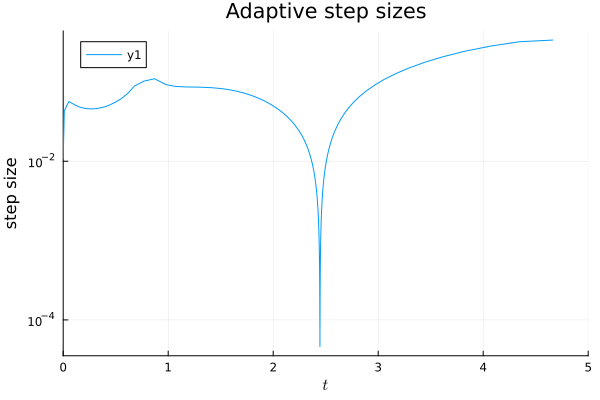

In [2]:
Δt = diff(t)
plot(t[1:end-1], Δt;
    xaxis=(L"t", (0, 5)), yaxis=(:log10, "step size"), title="Adaptive step sizes")

If we had to run with a uniform step size to get this accuracy, it would be

In [ ]:
println("minimum step size = $(minimum(Δt))")

On the other hand, the average step size that was actually taken was

In [ ]:
println("average step size = $(sum(Δt)/(length(t)-1))")

We took fewer steps by a factor of almost 1000! Even accounting for the extra stage per step and the occasional rejected step, the savings are clear.

## Example 6.5.2

In @demo-basics-sing we saw an IVP that appears to blow up in a finite amount of time. Because the solution increases so rapidly as it approaches the blowup, adaptive stepping is required even to get close.

In [ ]:
using OrdinaryDiffEq, FNCFunctions
f(u, p, t) = (t + u)^2
ivp = ODEProblem(f, 1, (0.0, 1.0))
t, u = FNC.rk23(ivp, 1e-5);

┌ Warning: Stepsize too small near t=0.7854087204072808
└ @ FNCFunctions /Users/driscoll/.julia/packages/FNCFunctions/b44xn/src/chapter06.jl:102


In fact, the failure of the adaptivity gives a decent idea of when the singularity occurs.

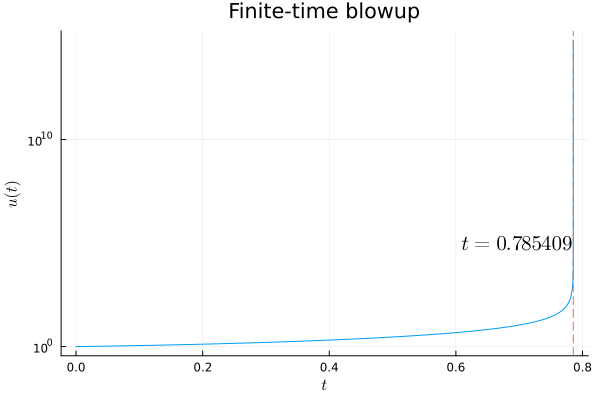

In [7]:
using Plots, LaTeXStrings, Printf
plot(t, u;
    legend=:none,
    xlabel=L"t",  yaxis=(:log10, L"u(t)"), 
    title="Finite-time blowup")

tf = t[end]
vline!([tf], l=:dash)
annotate!(tf, 1e5, latexstring(@sprintf("t = %.6f ", tf)), :right)